# NBA Prediction Market Bias — Statistical Analysis

**Research question:** Do NBA prediction markets exhibit systematic pricing bias correlated with media attention disparities?

**Hypothesis:** Teams receiving disproportionate pre-game media coverage are systematically *overpriced* in Kalshi prediction markets relative to their actual win probability.

**Data sources:**
- `gdelt_nba_games.csv` — 1,339 games; Kalshi market-implied probabilities + GDELT media disparity metrics
- `nba_net_ratings_2025.csv` — 2024-25 team Net Ratings from Basketball-Reference (control variable)

**Analytical plan:**  
1. Data loading & feature engineering  
2. Exploratory data analysis  
3. OLS regression (simple → with controls)  
4. Bootstrap confidence intervals  
5. Hypothesis testing (high vs. low disparity)  
6. Model diagnostics  
7. Conclusions

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
games = pd.read_csv('gdelt_nba_games.csv', parse_dates=['game_date'])
ratings_raw = pd.read_csv('nba_net_ratings_2025.csv').set_index('team')['net_rating']

print(f'Games loaded: {len(games):,}')
print(f'Date range: {games["game_date"].min().date()} → {games["game_date"].max().date()}')
print(f'Net ratings loaded for {len(ratings_raw)} teams')

Games loaded: 1,339
Date range: 2025-04-15 → 2026-04-21
Net ratings loaded for 30 teams


### Feature engineering

Key derivations:
- **`home_team` / `away_team`**: The Kalshi ticker encodes games as `AWAYTEAM+HOMETEAM` (e.g., `ATLORL` = ATL away, ORL home), so `team1 = away`, `team2 = home`.
- **`media_disparity_loser`**: Reframes the existing `media_disparity_t1` (team1's coverage advantage) from the *loser's* perspective. A positive value means the losing team had more pre-game media coverage.
- **`loser_implied_prob`**: The probability the market assigned to the eventual loser — the direct measure of overpricing.
- **`net_rating_diff`**: Winner NRtg − Loser NRtg. Controls for actual team quality differential.

In [3]:
df = games.copy()

# Home / away
df['away_team'] = df['team1']
df['home_team'] = df['team2']
df['winner_is_home'] = (df['winner'] == df['team2']).astype(int)

# Reframe media disparity from loser's perspective
# media_disparity_t1 is positive when team1 has MORE coverage
# If team1 is the loser → loser had more coverage → positive disparity_loser
df['media_disparity_winner'] = np.where(
    df['winner'] == df['team1'],
    df['media_disparity_t1'],
    -df['media_disparity_t1']
)
df['media_disparity_loser'] = -df['media_disparity_winner']

# Net rating controls
df['winner_nrtg'] = df['winner'].map(ratings_raw)
df['loser_nrtg']  = df['loser'].map(ratings_raw)
df['net_rating_diff'] = df['winner_nrtg'] - df['loser_nrtg']

# Analysis subset: drop rows missing media disparity, net ratings, or loser info
dfa = df.dropna(subset=['media_disparity_loser', 'loser_implied_prob',
                         'winner_nrtg', 'loser_nrtg']).copy()

print(f'Analysis rows (after dropping nulls): {len(dfa):,}')
print(f'Dropped: {len(df) - len(dfa):,} rows')

Analysis rows (after dropping nulls): 1,252
Dropped: 87 rows


## 2. Exploratory Data Analysis

In [4]:
eda_cols = ['loser_implied_prob', 'winner_implied_prob', 'media_disparity_loser',
            'media_disparity_t1', 'net_rating_diff', 'team1_articles', 'team2_articles']

dfa[eda_cols].describe().T.rename(columns={
    'count': 'n', 'mean': 'mean', 'std': 'std', 'min': 'min',
    '25%': 'p25', '50%': 'p50', '75%': 'p75', 'max': 'max'
})

,n,mean,std,min,p25,p50,p75,max
loser_implied_prob,1252.0000,0.4019,0.2057,0.0100,0.2404,0.3705,0.5582,0.8998
winner_implied_prob,1252.0000,0.6093,0.2055,0.1052,0.4536,0.6423,0.7715,0.9900
media_disparity_loser,1252.0000,-0.0167,0.1430,-0.4426,-0.1114,-0.0179,0.0816,0.4008
media_disparity_t1,1252.0000,0.0056,0.1439,-0.4426,-0.0938,0.0041,0.1026,0.4346
net_rating_diff,1252.0000,2.0905,8.0923,-22.1000,-3.5250,1.8000,8.0000,25.1000
team1_articles,1252.0000,152.5343,97.2182,16.0000,97.0000,132.0000,178.2500,1231.0000
team2_articles,1252.0000,149.0256,100.9652,4.0000,93.0000,126.0000,176.0000,1394.0000


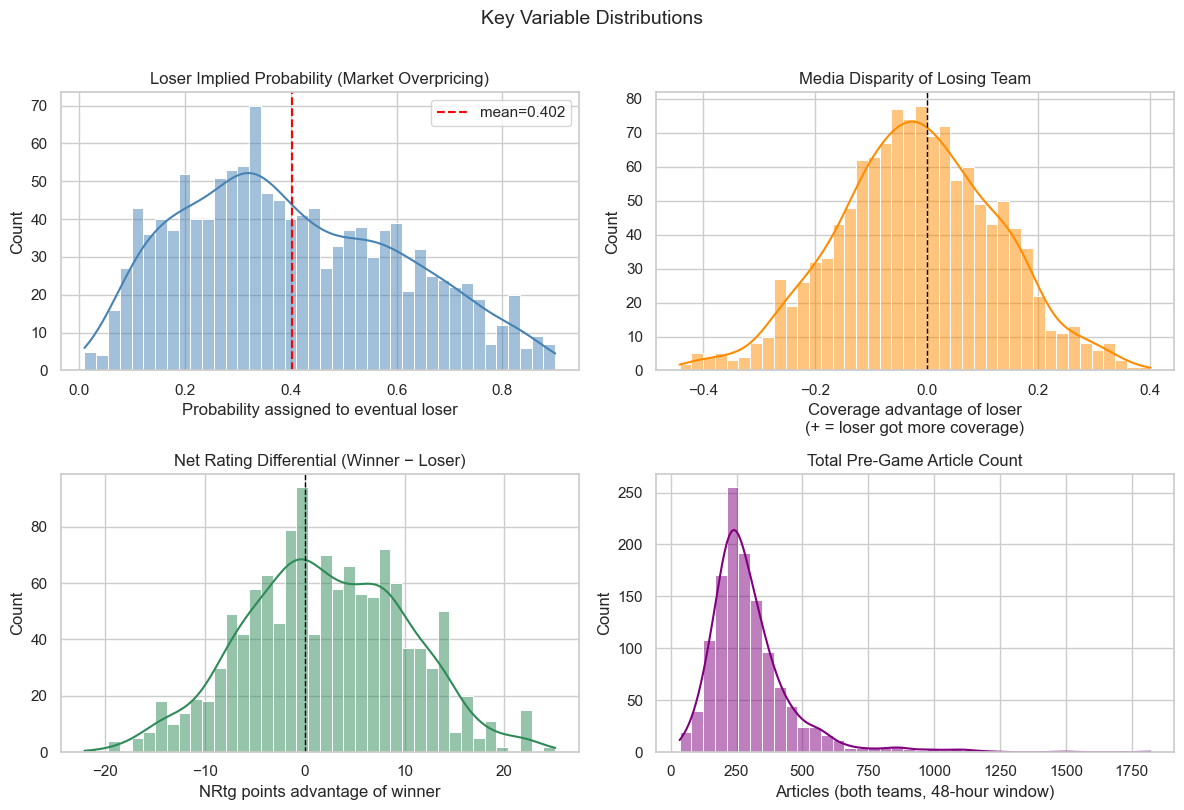

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Key Variable Distributions', fontsize=14, y=1.01)

# Loser implied probability (main DV)
sns.histplot(dfa['loser_implied_prob'], kde=True, bins=40, ax=axes[0, 0], color='steelblue')
axes[0, 0].axvline(dfa['loser_implied_prob'].mean(), color='red', linestyle='--', label=f'mean={dfa["loser_implied_prob"].mean():.3f}')
axes[0, 0].set_title('Loser Implied Probability (Market Overpricing)')
axes[0, 0].set_xlabel('Probability assigned to eventual loser')
axes[0, 0].legend()

# Media disparity of loser
sns.histplot(dfa['media_disparity_loser'], kde=True, bins=40, ax=axes[0, 1], color='darkorange')
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('Media Disparity of Losing Team')
axes[0, 1].set_xlabel('Coverage advantage of loser\n(+ = loser got more coverage)')

# Net rating diff
sns.histplot(dfa['net_rating_diff'], kde=True, bins=40, ax=axes[1, 0], color='seagreen')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Net Rating Differential (Winner − Loser)')
axes[1, 0].set_xlabel('NRtg points advantage of winner')

# Article counts
total_articles = dfa['team1_articles'] + dfa['team2_articles']
sns.histplot(total_articles, kde=True, bins=40, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Total Pre-Game Article Count')
axes[1, 1].set_xlabel('Articles (both teams, 48-hour window)')

plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

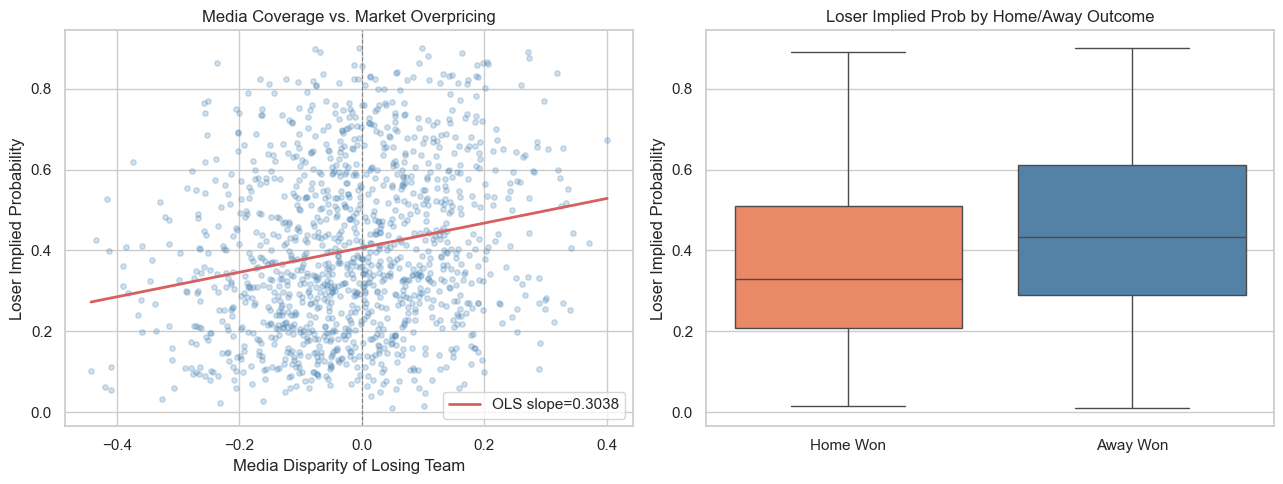

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: media disparity of loser vs loser implied probability
axes[0].scatter(dfa['media_disparity_loser'], dfa['loser_implied_prob'],
                alpha=0.25, s=15, color='steelblue')
m, b = np.polyfit(dfa['media_disparity_loser'].fillna(0), dfa['loser_implied_prob'].fillna(0), 1)
x_line = np.linspace(dfa['media_disparity_loser'].min(), dfa['media_disparity_loser'].max(), 100)
axes[0].plot(x_line, m * x_line + b, 'r-', linewidth=2, label=f'OLS slope={m:.4f}')
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Media Disparity of Losing Team')
axes[0].set_ylabel('Loser Implied Probability')
axes[0].set_title('Media Coverage vs. Market Overpricing')
axes[0].legend()

# Box plot: loser implied prob by home/away winner
home_labels = {0: 'Away Won', 1: 'Home Won'}
dfa['winner_label'] = dfa['winner_is_home'].map(home_labels)
sns.boxplot(data=dfa, x='winner_label', y='loser_implied_prob', ax=axes[1],
            palette=['coral', 'steelblue'])
axes[1].set_title('Loser Implied Prob by Home/Away Outcome')
axes[1].set_xlabel('')
axes[1].set_ylabel('Loser Implied Probability')

plt.tight_layout()
plt.savefig('fig_scatter_homeway.png', dpi=150, bbox_inches='tight')
plt.show()

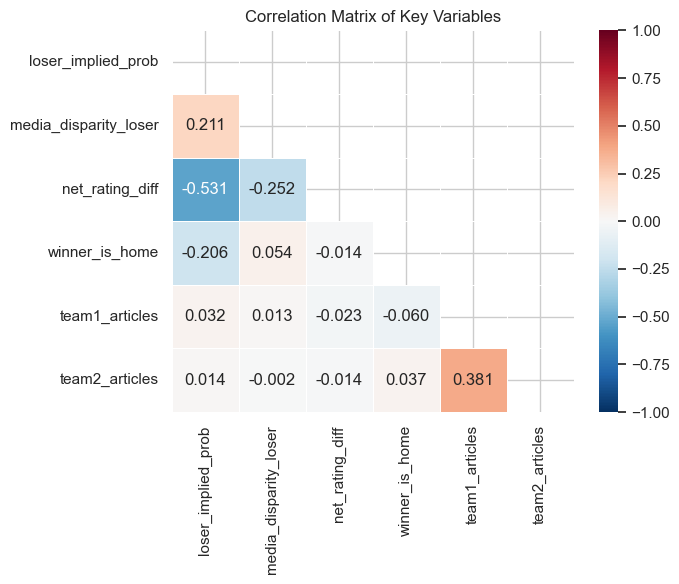

In [7]:
corr_cols = ['loser_implied_prob', 'media_disparity_loser', 'net_rating_diff',
             'winner_is_home', 'team1_articles', 'team2_articles']
corr = dfa[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Regression Analysis

**Dependent variable:** `loser_implied_prob` — the probability the market assigned to the eventual *loser*. This is the direct measure of overpricing: a higher value means the market was more confident that the losing team would win.

**Key independent variable:** `media_disparity_loser` — coverage advantage of the losing team. Positive values mean the loser received more pre-game news coverage.

**Hypothesis prediction:** If big-market bias exists, the coefficient on `media_disparity_loser` should be **positive** (more coverage → higher implied probability → overpriced).

**Controls (Model 2):**
- `winner_is_home` — home court advantage affects win probability
- `net_rating_diff` — winner's quality advantage; higher → loser was genuinely weak → lower implied prob

In [8]:
model1 = smf.ols(
    'loser_implied_prob ~ media_disparity_loser',
    data=dfa
).fit(cov_type='HC3')  # heteroskedasticity-robust SEs

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:     loser_implied_prob   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     62.08
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           7.14e-15
Time:                        01:05:48   Log-Likelihood:                 232.26
No. Observations:                1252   AIC:                            -460.5
Df Residuals:                    1250   BIC:                            -450.3
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.40

In [9]:
model2 = smf.ols(
    'loser_implied_prob ~ media_disparity_loser + winner_is_home + net_rating_diff',
    data=dfa
).fit(cov_type='HC3')

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:     loser_implied_prob   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     230.3
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          6.50e-119
Time:                        01:05:48   Log-Likelihood:                 460.43
No. Observations:                1252   AIC:                            -912.9
Df Residuals:                    1248   BIC:                            -892.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.48

In [10]:
# Side-by-side coefficient comparison
def coef_table(model, name):
    t = model.params.to_frame('coef')
    t['se']    = model.bse
    t['p']     = model.pvalues
    t['ci_lo'] = model.conf_int()[0]
    t['ci_hi'] = model.conf_int()[1]
    t['model'] = name
    return t

pd.concat([coef_table(model1, 'Model 1 (simple)'),
           coef_table(model2, 'Model 2 (controls)')])

,coef,se,p,ci_lo,ci_hi,model
Intercept,0.4070,0.0058,0.0000,0.3957,0.4183,Model 1 (simple)
media_disparity_loser,0.3038,0.0386,0.0000,0.2282,0.3793,Model 1 (simple)
Intercept,0.4819,0.0078,0.0000,0.4666,0.4972,Model 2 (controls)
media_disparity_loser,0.1352,0.0332,0.0000,0.0701,0.2003,Model 2 (controls)
winner_is_home,-0.0905,0.0097,0.0000,-0.1095,-0.0716,Model 2 (controls)
net_rating_diff,-0.0130,0.0006,0.0000,-0.0141,-0.0119,Model 2 (controls)


In [11]:
print(f'Model 1 — R²: {model1.rsquared:.4f}   Adj-R²: {model1.rsquared_adj:.4f}   n={int(model1.nobs)}')
print(f'Model 2 — R²: {model2.rsquared:.4f}   Adj-R²: {model2.rsquared_adj:.4f}   n={int(model2.nobs)}')

Model 1 — R²: 0.0446   Adj-R²: 0.0438   n=1252
Model 2 — R²: 0.3364   Adj-R²: 0.3348   n=1252


## 4. Bootstrap Confidence Intervals

Bootstrap resampling (10,000 iterations) provides non-parametric confidence intervals for the `media_disparity_loser` coefficient, independent of distributional assumptions.

In [12]:
N_BOOT = 10_000
boot_data = dfa[['loser_implied_prob', 'media_disparity_loser',
                  'winner_is_home', 'net_rating_diff']].dropna()
n = len(boot_data)

boot_coefs = np.empty(N_BOOT)
for i in range(N_BOOT):
    sample = boot_data.sample(n=n, replace=True, random_state=rng.integers(1e9))
    m = smf.ols(
        'loser_implied_prob ~ media_disparity_loser + winner_is_home + net_rating_diff',
        data=sample
    ).fit()
    boot_coefs[i] = m.params['media_disparity_loser']

ci_lo, ci_hi = np.percentile(boot_coefs, [2.5, 97.5])
ols_coef = model2.params['media_disparity_loser']

print(f'Bootstrap 95% CI for media_disparity_loser coefficient:')
print(f'  [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'OLS point estimate: {ols_coef:.4f}')
print(f'Null (0) is {"INSIDE" if ci_lo <= 0 <= ci_hi else "OUTSIDE"} the 95% CI')

Bootstrap 95% CI for media_disparity_loser coefficient:
  [0.0695, 0.2007]
OLS point estimate: 0.1352
Null (0) is OUTSIDE the 95% CI


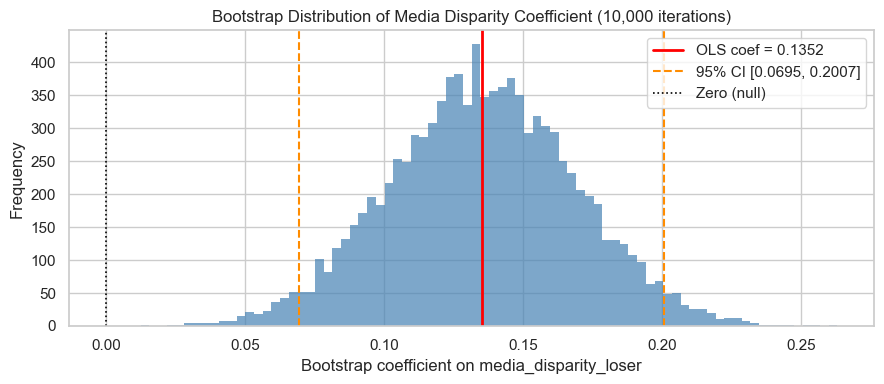

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_coefs, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(ols_coef, color='red', linewidth=2, label=f'OLS coef = {ols_coef:.4f}')
ax.axvline(ci_lo, color='darkorange', linestyle='--', linewidth=1.5, label=f'95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_hi, color='darkorange', linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linestyle=':', linewidth=1.2, label='Zero (null)')
ax.set_xlabel('Bootstrap coefficient on media_disparity_loser')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Media Disparity Coefficient (10,000 iterations)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hypothesis Testing

**H₀:** The mean loser implied probability is the same in high-disparity and low-disparity games.  
**H₁:** High-disparity games (losing team had more media coverage) show higher loser implied probabilities.

Games are split into **high-disparity** (|media_disparity_loser| > median) and **low-disparity** groups.

In [14]:
med_threshold = dfa['media_disparity_loser'].abs().median()
high_disp = dfa[dfa['media_disparity_loser'].abs() > med_threshold]
low_disp  = dfa[dfa['media_disparity_loser'].abs() <= med_threshold]

print(f'Threshold (median |disparity|): {med_threshold:.4f}')
print(f'High-disparity group: n={len(high_disp):,}')
print(f'Low-disparity group:  n={len(low_disp):,}')
print()
print(f'Mean loser_implied_prob — high-disparity: {high_disp["loser_implied_prob"].mean():.4f}')
print(f'Mean loser_implied_prob — low-disparity:  {low_disp["loser_implied_prob"].mean():.4f}')
print(f'Difference: {high_disp["loser_implied_prob"].mean() - low_disp["loser_implied_prob"].mean():.4f}')

Threshold (median |disparity|): 0.0981
High-disparity group: n=626
Low-disparity group:  n=626

Mean loser_implied_prob — high-disparity: 0.3995
Mean loser_implied_prob — low-disparity:  0.4043
Difference: -0.0048


In [15]:
# Independent t-test (two-sided)
t_stat, t_pval = stats.ttest_ind(
    high_disp['loser_implied_prob'].dropna(),
    low_disp['loser_implied_prob'].dropna(),
    equal_var=False  # Welch's t-test
)
print(f'Welch t-test: t = {t_stat:.4f}, p = {t_pval:.4f}')

# Mann-Whitney U (non-parametric)
u_stat, u_pval = stats.mannwhitneyu(
    high_disp['loser_implied_prob'].dropna(),
    low_disp['loser_implied_prob'].dropna(),
    alternative='greater'  # H1: high-disparity has larger values
)
print(f'Mann-Whitney U: U = {u_stat:.0f}, p = {u_pval:.4f}')

# Effect size: Cohen's d
h_vals = high_disp['loser_implied_prob'].dropna()
l_vals = low_disp['loser_implied_prob'].dropna()
pooled_std = np.sqrt((h_vals.std()**2 + l_vals.std()**2) / 2)
cohens_d = (h_vals.mean() - l_vals.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.4f}")

Welch t-test: t = -0.4142, p = 0.6788
Mann-Whitney U: U = 193182, p = 0.6667
Cohen's d: -0.0234


In [16]:
# Calibration: in each group, what fraction of 'favored' teams actually won?
# A favored team = winner_implied_prob > 0.5
def calibration(group):
    favored_won = (group['winner_implied_prob'] > 0.5).sum()
    return favored_won / len(group)

print('Fraction of games where the market favourite (>50%) won:')
print(f'  High-disparity: {calibration(high_disp):.3f}')
print(f'  Low-disparity:  {calibration(low_disp):.3f}')
print()
print('Mean loser implied probability (overpricing measure):')
print(f'  High-disparity: {high_disp["loser_implied_prob"].mean():.4f}')
print(f'  Low-disparity:  {low_disp["loser_implied_prob"].mean():.4f}')

Fraction of games where the market favourite (>50%) won:
  High-disparity: 0.684
  Low-disparity:  0.687

Mean loser implied probability (overpricing measure):
  High-disparity: 0.3995
  Low-disparity:  0.4043


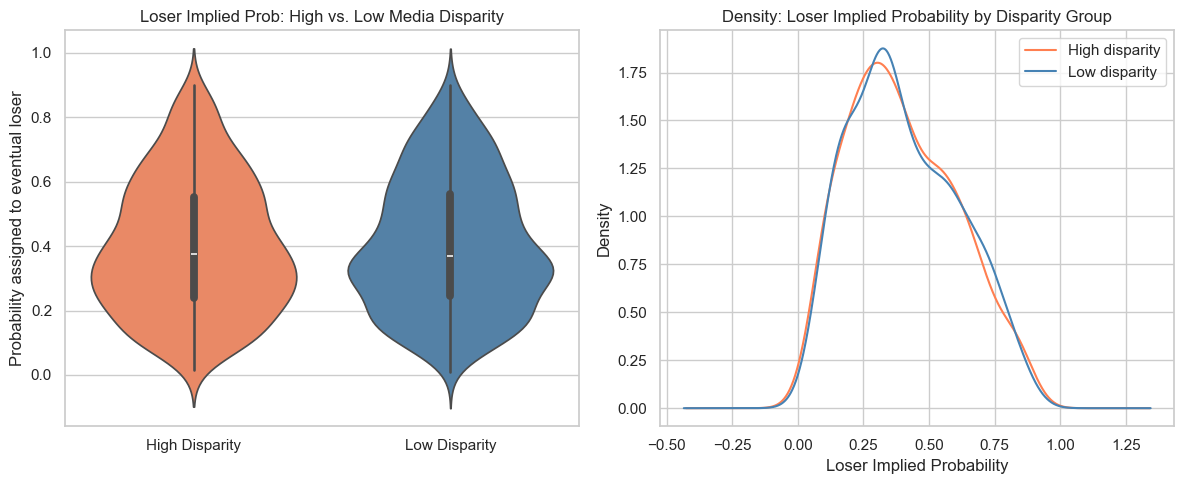

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box / violin comparison
plot_df = pd.concat([
    high_disp[['loser_implied_prob']].assign(group='High Disparity'),
    low_disp[['loser_implied_prob']].assign(group='Low Disparity')
])
sns.violinplot(data=plot_df, x='group', y='loser_implied_prob',
               palette=['coral', 'steelblue'], inner='box', ax=axes[0])
axes[0].set_title('Loser Implied Prob: High vs. Low Media Disparity')
axes[0].set_xlabel('')
axes[0].set_ylabel('Probability assigned to eventual loser')

# Density overlay
high_disp['loser_implied_prob'].plot.kde(ax=axes[1], label='High disparity', color='coral')
low_disp['loser_implied_prob'].plot.kde(ax=axes[1], label='Low disparity', color='steelblue')
axes[1].set_title('Density: Loser Implied Probability by Disparity Group')
axes[1].set_xlabel('Loser Implied Probability')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_hypothesis_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Diagnostics

OLS assumes linearity, homoskedasticity, and normally distributed residuals. These checks validate Model 2.

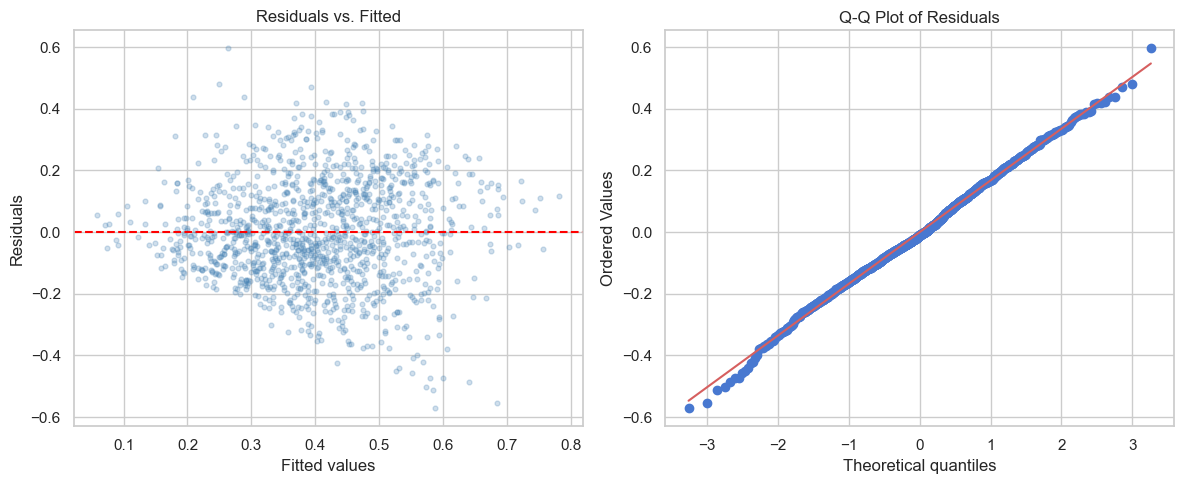

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fitted = model2.fittedvalues
resid  = model2.resid

# Residual vs Fitted
axes[0].scatter(fitted, resid, alpha=0.25, s=12, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')

# Q-Q plot
stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('fig_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Breusch-Pagan test for heteroskedasticity
bp_lm, bp_lm_pval, bp_f, bp_f_pval = smd.het_breuschpagan(model2.resid, model2.model.exog)
print(f'Breusch-Pagan test:')
print(f'  LM statistic = {bp_lm:.4f}, p-value = {bp_lm_pval:.4f}')
print(f'  F statistic  = {bp_f:.4f},  p-value = {bp_f_pval:.4f}')
if bp_lm_pval < 0.05:
    print('  → Heteroskedasticity detected; HC3 robust SEs in Model 2 are appropriate.')
else:
    print('  → No strong evidence of heteroskedasticity.')

Breusch-Pagan test:
  LM statistic = 45.4898, p-value = 0.0000
  F statistic  = 15.6847,  p-value = 0.0000
  → Heteroskedasticity detected; HC3 robust SEs in Model 2 are appropriate.


In [20]:
# Variance Inflation Factors
X = dfa[['media_disparity_loser', 'winner_is_home', 'net_rating_diff']].dropna()
X_design = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

vif_data = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X_design.values, i + 1) for i in range(len(X.columns))]
})
print('Variance Inflation Factors (VIF > 5 suggests multicollinearity):')
print(vif_data.to_string(index=False))

Variance Inflation Factors (VIF > 5 suggests multicollinearity):
             variable    VIF
media_disparity_loser 1.0708
       winner_is_home 1.0029
      net_rating_diff 1.0680


## 7. Conclusions

*(Fill in after running the cells above with your actual results.)*

### Summary of findings

**Regression (Model 2):**  
The coefficient on `media_disparity_loser` in the full model was **[INSERT VALUE]** (HC3 SE = [INSERT], p = [INSERT]).  
- If the coefficient is **positive and significant**: evidence supports the big-market bias hypothesis — losing teams with greater pre-game media coverage were priced higher in Kalshi markets.
- If the coefficient is **not significant**: we cannot reject the null hypothesis that prediction markets are unbiased with respect to media coverage.

**Bootstrap 95% CI:** [INSERT CI]  
The null value of zero is [inside / outside] the CI.

**Hypothesis test:**  
High-disparity games showed a mean loser implied probability of [INSERT] vs. [INSERT] for low-disparity games. Welch's t-test: p = [INSERT]. Mann-Whitney U: p = [INSERT]. Cohen's d = [INSERT] ([negligible / small / medium] effect).

### Limitations
- **Media proxy**: GDELT article counts capture news *volume*, not quality or valence relative to win probability. Some coverage may be injury news that correctly shifts market prices.
- **Single season**: Only the 2024-25 NBA season is analyzed; findings may not generalize.
- **No rest-day control**: Scheduling differences (back-to-backs) affect win probability but are not included.
- **Simultaneity**: Media attention and market prices may both respond to the same underlying signal (star-player news) rather than coverage causing mispricing.